In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("house_prices_dataset.csv")

In [8]:
df

,area,price
0,2231.88,558852.17
1,2524.92,632260.29
2,1527.65,382994.25
3,1986.09,497607.86
4,2920.16,730870.84
...,...,...
95,2345.42,587342.25
96,1701.95,426321.81
97,2880.39,721159.46
98,2273.60,569238.36


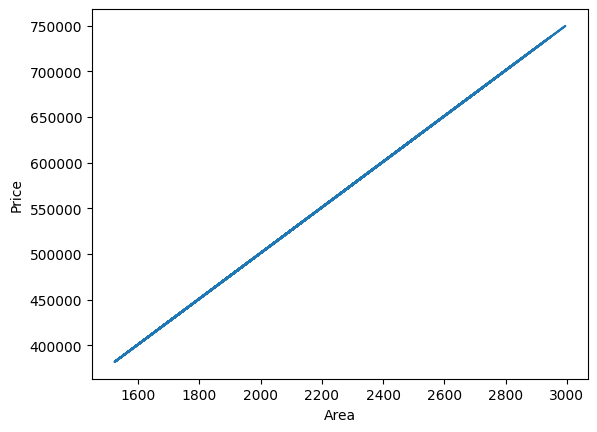

In [9]:
plt.plot(df["area"],df["price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split 

In [16]:
x_train, x_test , y_train ,y_test = train_test_split(df["area"],df["price"],random_state=42,test_size=0.2,train_size=0.8)

In [20]:
y_test.shape

(20,)

In [29]:
# convert dataframe to numpy arrays
x_arr = x_train.to_numpy()
y_arr = y_train.to_numpy()
print(x_arr)
print(y_arr)

[1522.16 2260.8  1990.05 2873.79 1898.42 2306.34 1581.99 1701.95 2836.94
 1645.76 2043.63 1947.02 2557.51 2574.26 2359.56 2821.46 2677.54 2462.76
 1601.51 2823.63 2214.04 2931.6  1660.93 2345.42 1793.01 2175.01 2189.35
 2593.21 1828.2  2617.25 2619.16 1986.09 2566.89 2470.42 1960.97 1524.86
 1617.55 1995.65 2676.79 2367.9  2306.25 2923.85 2941.01 1814.85 2949.39
 2995.4  2649.11 2343.55 2225.26 2880.39 1858.84 2612.27 1895.44 2418.39
 2273.6  2047.23 2158.54 1570.37 2517.89 1925.99 1762.2  1935.77 2051.5
 2479.35 2524.92 1546.52 1728.91 1527.65 2340.5  2785.27 1806.84 1654.49
 1526.64 2253.37 2446.49 1693.2  2437.16 2887.84 1669.9  2585.33]
[381657.07 566293.29 498600.7  719276.32 475667.09 577782.98 396479.43
 426321.81 710394.29 412327.88 512023.93 487733.22 640315.12 644398.17
 590800.94 706324.52 670488.03 616710.69 401452.23 707043.03 554450.9
 733878.14 416215.31 587342.25 449362.17 544621.68 548516.57 649133.21
 458129.23 655321.99 655662.94 497607.86 642617.3  618659.26 491366.

In [ ]:
# normalisation
x_mean = x_arr.mean()
x_std = x_arr.std()

x_norm = (x_arr - x_mean) / x_std


In [55]:
# hypothesis function
def hypo(theta,xi):
    return (theta[0]+theta[1]*xi)

In [61]:
def regression(x_norm , y_arr , step ,max_itr):
    J_theta = 1
    theta=[1,1]
    error=[]
    m=x_norm.shape[0]
    for i in range(max_itr):
        grad_0 =(1/m)*(np.sum(hypo(theta,x_norm)-1*y_arr))
        grad_1 =(1/m)*(np.sum((hypo(theta,x_norm)-1*y_arr)*x_norm))
        J_theta = (1/m)*np.sum((hypo(theta,x_norm)-1*y_arr)*(hypo(theta,x_norm)-1*y_arr))
        error.append(J_theta)
        theta[0]=theta[0]-step*grad_0
        theta[1]=theta[1]-step*grad_1
        if np.isnan(J_theta) or np.isinf(J_theta):
            print("Diverged ❌")
            break
    return theta,error

[np.float64(555922.479875), np.float64(110059.61203394318)]
[np.float64(321161601109.43304), np.float64(11240.184948769323), np.float64(11240.184948768776), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(11240.184948768483), np.float64(

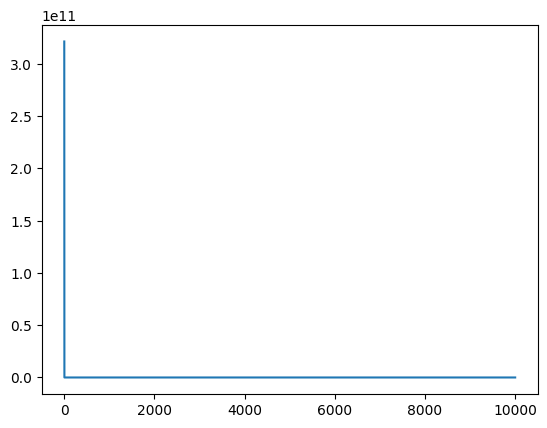

In [76]:
theta , error = regression(x_norm,y_arr,1,10000)
print(theta)
print(error)
plt.plot(error)
plt.show()

[np.float64(555922.4798749995), np.float64(110059.6120339431)]
[np.float64(321161601109.43304), np.float64(260140899034.27588), np.float64(210714130353.3986), np.float64(170678447721.888), np.float64(138249544790.36444), np.float64(111982133415.83032), np.float64(90705530202.4577), np.float64(73471481599.6259), np.float64(59511902231.33211), np.float64(48204642943.01416), np.float64(39045762919.4766), np.float64(31627070100.411182), np.float64(25617928916.9682), np.float64(20750524558.37938), np.float64(16807927027.922438), np.float64(13614423028.252316), np.float64(11027684788.51952), np.float64(8932426814.335943), np.float64(7235267855.24726), np.float64(5860569098.385426), np.float64(4747063105.327332), np.float64(3845123250.950281), np.float64(3114551968.9048676), np.float64(2522789230.4480815), np.float64(2043461412.2980843), np.float64(1655205879.5965893), np.float64(1340718898.1083794), np.float64(1085984443.1029298), np.float64(879649534.5485101), np.float64(712518258.6194319),

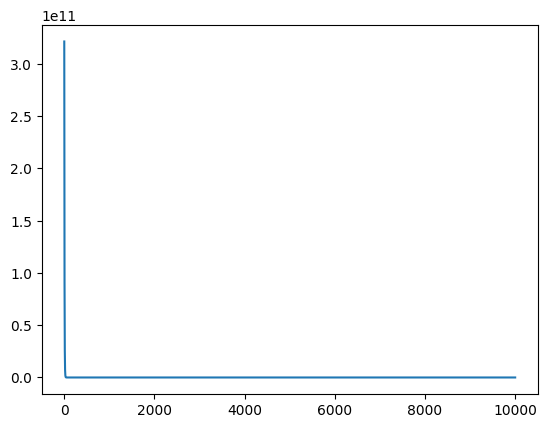

In [77]:
theta , error = regression(x_norm,y_arr,0.1,10000)
print(theta)
print(error)
plt.plot(error)
plt.show()

[np.float64(555922.4798749943), np.float64(110059.61203394245)]
[np.float64(321161601109.43304), np.float64(314770485471.035), np.float64(308506553033.841), np.float64(302367272852.1473), np.float64(296350164346.0692), np.float64(290452796299.26215), np.float64(284672785876.5865), np.float64(279007797661.3221), np.float64(273455542711.5415), np.float64(268013777635.26154), np.float64(262680303683.99948), np.float64(257452965864.36758), np.float64(252329652067.3463), np.float64(247308292214.88586), np.float64(242386857423.48926), np.float64(237563359184.44153), np.float64(232835848560.3508), np.float64(228202415397.6795), np.float64(223661187554.94537), np.float64(219210330146.28165), np.float64(214848044800.05032), np.float64(210572568932.20898), np.float64(206382175034.1377), np.float64(202275169974.63806), np.float64(198249894315.82245), np.float64(194304721642.61725), np.float64(190438057905.60886), np.float64(186648340776.96692), np.float64(182934039019.18497), np.float64(179293651

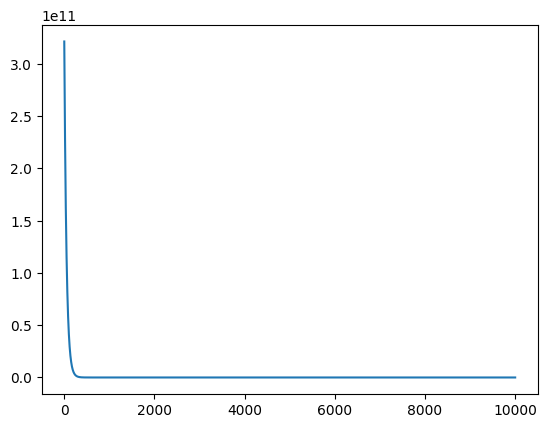

In [78]:
theta , error = regression(x_norm,y_arr,0.01,10000)
print(theta)
print(error)
plt.plot(error)
plt.show()

[np.float64(555897.3670416535), np.float64(110054.64031818417)]
[np.float64(321161601109.43304), np.float64(320519599091.28436), np.float64(319878880435.17004), np.float64(319239442575.6493), np.float64(318601282952.40967), np.float64(317964399010.25696), np.float64(317328788199.1046), np.float64(316694447973.9637), np.float64(316061375794.93286), np.float64(315429569127.1879), np.float64(314799025440.9718), np.float64(314169742211.5844), np.float64(313541716919.37256), np.float64(312914947049.71985), np.float64(312289430093.0366), np.float64(311665163544.7498), np.float64(311042144905.29297), np.float64(310420371680.09644), np.float64(309799841379.5771), np.float64(309180551519.12836), np.float64(308562499619.1108), np.float64(307945683204.8413), np.float64(307330099806.5839), np.float64(306715746959.5397), np.float64(306102622203.83673), np.float64(305490723084.5204), np.float64(304880047151.5436), np.float64(304270591959.7568), np.float64(303662355068.8984), np.float64(303055334043.

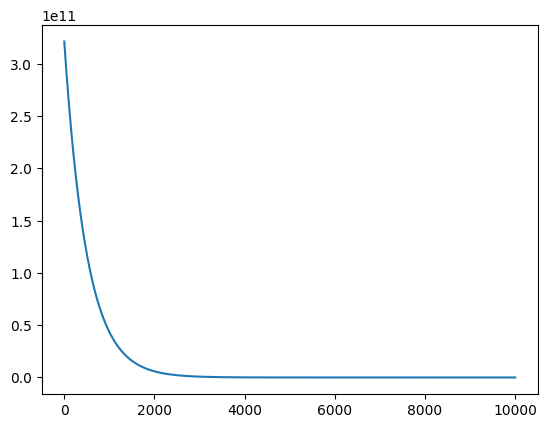

In [79]:
theta , error = regression(x_norm,y_arr,0.001,10000)
print(theta)
print(error)
plt.plot(error)
plt.show()

[np.float64(351420.62255363894), np.float64(69573.335842181)]
[np.float64(321161601109.43304), np.float64(321097372003.075), np.float64(321033155741.8961), np.float64(320968952323.3272), np.float64(320904761744.8), np.float64(320840584003.7466), np.float64(320776419097.59955), np.float64(320712267023.7922), np.float64(320648127779.758), np.float64(320584001362.9313), np.float64(320519887770.7466), np.float64(320455787000.6393), np.float64(320391699050.0449), np.float64(320327623916.39984), np.float64(320263561597.1407), np.float64(320199512089.7048), np.float64(320135475391.5299), np.float64(320071451500.0543), np.float64(320007440412.71674), np.float64(319943442126.9565), np.float64(319879456640.21344), np.float64(319815483949.9279), np.float64(319751524053.5407), np.float64(319687576948.4931), np.float64(319623642632.2272), np.float64(319559721102.18506), np.float64(319495812355.80975), np.float64(319431916390.5446), np.float64(319368033203.8336), np.float64(319304162793.12115), np.f

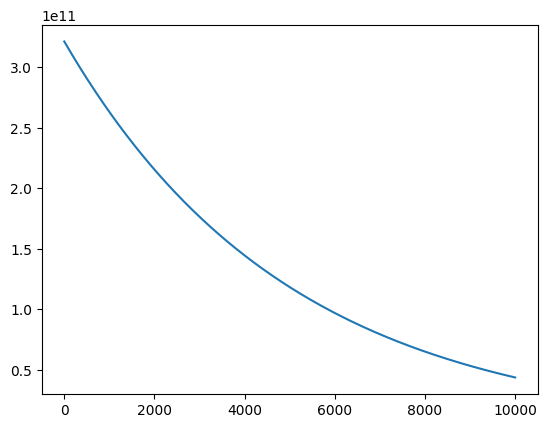

In [80]:
theta , error = regression(x_norm,y_arr,0.0001,10000)
print(theta)
print(error)
plt.plot(error)
plt.show()

In [82]:
theta , error = regression(x_norm,y_arr,0.001,10000)
print(theta)
print(error)

[np.float64(555897.3670416535), np.float64(110054.64031818417)]
[np.float64(321161601109.43304), np.float64(320519599091.28436), np.float64(319878880435.17004), np.float64(319239442575.6493), np.float64(318601282952.40967), np.float64(317964399010.25696), np.float64(317328788199.1046), np.float64(316694447973.9637), np.float64(316061375794.93286), np.float64(315429569127.1879), np.float64(314799025440.9718), np.float64(314169742211.5844), np.float64(313541716919.37256), np.float64(312914947049.71985), np.float64(312289430093.0366), np.float64(311665163544.7498), np.float64(311042144905.29297), np.float64(310420371680.09644), np.float64(309799841379.5771), np.float64(309180551519.12836), np.float64(308562499619.1108), np.float64(307945683204.8413), np.float64(307330099806.5839), np.float64(306715746959.5397), np.float64(306102622203.83673), np.float64(305490723084.5204), np.float64(304880047151.5436), np.float64(304270591959.7568), np.float64(303662355068.8984), np.float64(303055334043.

<function matplotlib.pyplot.show(close=None, block=None)>

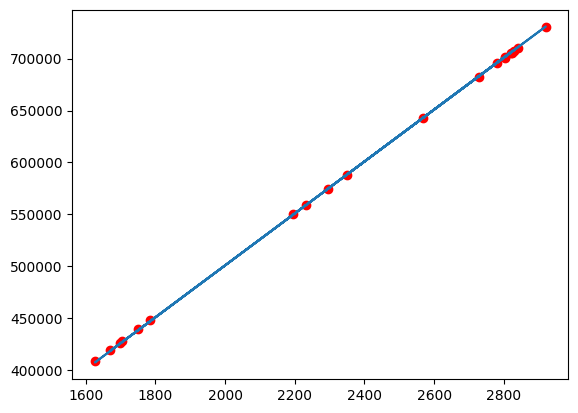

In [94]:
mean = x_train.mean()
std  = x_train.std()
x_test_norm=(x_test - mean) / std
y_pred = theta[1]*x_test_norm+theta[0]

plt.plot(x_test,y_test,linestyle="-")
plt.scatter(x_test,y_pred,c="red")
plt.show

In [102]:
# r square
y_mean = y_test.mean()
rss=np.sum((y_pred-y_test)**2)
tss=np.sum((y_test-y_mean)**2)
r2=1-rss/tss

print(r2)


0.9999562200350269
